                      ccb_3m  EURUSD basis swap 3m
ccb_3m                  1.00                  0.99
EURUSD basis swap 3m    0.99                  1.00


,month,ccb_3m,EURUSD basis swap 3m
133,2026-02-28,-2.03,0.38
134,2026-03-31,-2.47,-1.50
135,2026-04-30,-2.78,-0.25
136,2026-05-31,-2.69,-0.62
137,2026-06-30,-1.93,-0.25
138,2026-07-31,-0.44,1.12


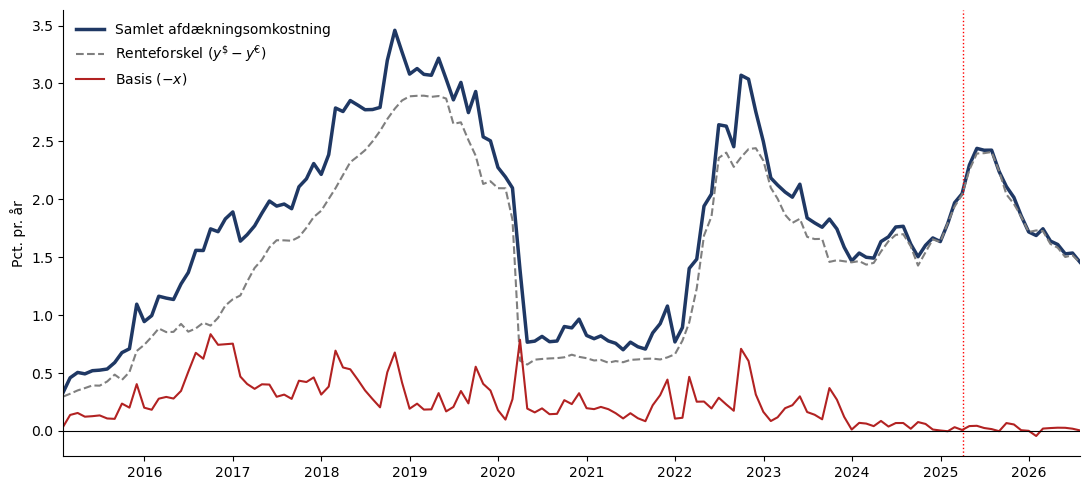

In [3]:
# %% 0) Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# %% 1) Data
BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
master = pd.read_csv(os.path.join(BASE, "clean", "master_monthly.csv"), parse_dates=["month"])
master = master.sort_values("month").reset_index(drop=True)

# %% 2) Cross-currency basis og afdækningsomkostning (Du, Tepper & Verdelhan 2018, lign. 2 og 4)
# DTV: S i euro pr. dollar = 1/EURUSD. Terminspoint i 1/10.000.
F = master["EURUSD"] + master["EUR3M"] / 10_000
master["rho"]          = -4 * (np.log(F) - np.log(master["EURUSD"])) * 100   # (f - s)/n, pct. p.a.
master["renteforskel"] = master["USD OIS 3m"] - master["EUR OIS 3m"]         # y$ - y€, pct. p.a.
master["ccb_3m"]       = (master["renteforskel"] + master["rho"]) * 100      # x = y$ - y€ + rho, bp
master["afd_omk"]      = -master["rho"]                                      # afdækningsomkostning, pct. p.a.

# Tjek mod markedets 3M-basis i den periode, hvor den findes
print(master[["ccb_3m", "EURUSD basis swap 3m"]].dropna().corr().round(2))
display(master[["month", "ccb_3m", "EURUSD basis swap 3m"]].dropna().tail(6).round(2))

# %% 3) Figur: afdækningsomkostningen opdelt i renteforskel og basis
d = master.dropna(subset=["afd_omk", "renteforskel", "ccb_3m"])        # kun måneder med data

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(d["month"], d["afd_omk"], color="#1f3864", lw=2.5, label="Samlet afdækningsomkostning")
ax.plot(d["month"], d["renteforskel"], color="#7f7f7f", lw=1.5, ls="--",
        label="Renteforskel ($y^{\\$} - y^{€}$)")
ax.plot(d["month"], -d["ccb_3m"] / 100, color="#b22222", lw=1.5, label="Basis ($-x$)")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(pd.Timestamp("2025-04-02"), color="red", lw=1, ls=":")
ax.set_xlim(d["month"].min(), d["month"].max())                         # første til sidste datapunkt
ax.set_ylabel("Pct. pr. år")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/afdaekningsomkostning.pdf", bbox_inches="tight")
plt.show()